In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
from tensorflow.keras.models import load_model
import tensorflow as tf

# 1. Load trained model
model = load_model("/content/drive/MyDrive/best_model.keras")
print("✅ Model loaded successfully!")

# 2. Build Grad-CAM Model Graph
LAST_CONV_LAYER = "conv5_block16_concat"  # Make sure this matches your architecture!

grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[model.get_layer(LAST_CONV_LAYER).output, model.output]
)
print("✅ Grad-CAM graph built successfully!")

✅ Model loaded successfully!
✅ Grad-CAM graph built successfully!


In [103]:
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing import image

def predict_and_explain(img_path):
    # 1. Preprocess
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # 2. Grad-CAM & Prediction
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    score = float(predictions.numpy()[0][0])
    label = "Pneumonia" if score > 0.7 else "Normal"

    # 3. Heatmap Overlay
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)

    original_img = cv2.imread(img_path)
    original_img = cv2.resize(original_img, (224, 224))

    overlay = cv2.addWeighted(original_img, 0.6, heatmap_colored, 0.4, 0)

    return {
        "score": score,
        "label": label,
        "overlay_image": overlay
    }

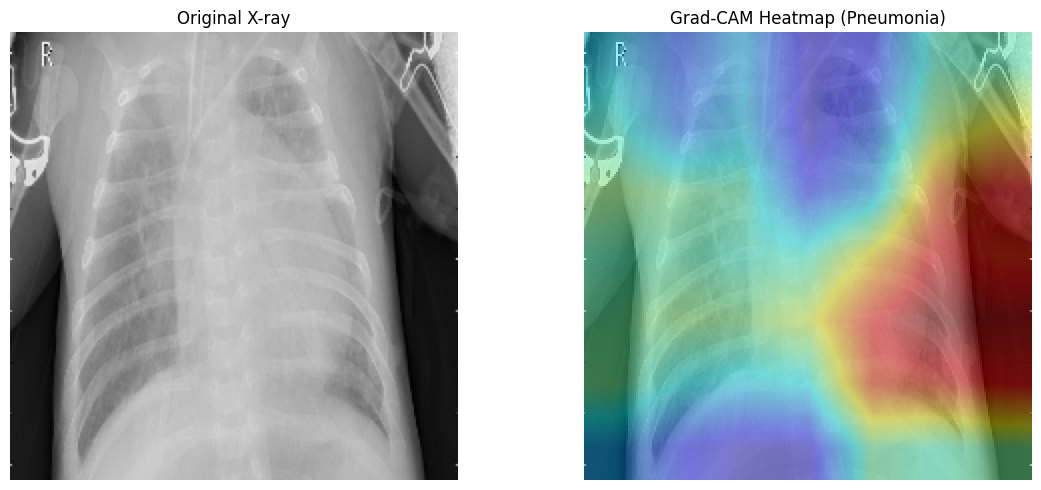

----------------------------------------
📊 DIAGNOSIS: Pneumonia
🎯 CONFIDENCE SCORE: 0.8913 (89.13%)
----------------------------------------


In [104]:
import matplotlib.pyplot as plt

# 1. Run inference
result = predict_and_explain("person1_virus_7.jpeg")

# 2. Re-create components for visual display
original_img = cv2.imread("person1_virus_7.jpeg")
original_img = cv2.resize(original_img, (224, 224))

# 3. Plot Original, Overlay, and Results together
plt.figure(figsize=(12, 5))

# Subplot 1: Original Image
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title("Original X-ray")
plt.axis("off")

# Subplot 2: Grad-CAM Overlay
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result["overlay_image"], cv2.COLOR_BGR2RGB))
plt.title(f"Grad-CAM Heatmap ({result['label']})")
plt.axis("off")

plt.tight_layout()
plt.show()

# 4. Print Summary Below
print("-" * 40)
print(f"📊 DIAGNOSIS: {result['label']}")
print(f"🎯 CONFIDENCE SCORE: {result['score']:.4f} ({result['score']*100:.2f}%)")
print("-" * 40)